In [47]:
import pandas as pd

coin = pd.read_csv(
    "/Users/lizeyu/Desktop/Quant-on-Crypto/strategies/mmpair-strategy/mmpair-strategy/1m_klines_raw/BTCUSDT_klines_1m.csv"
)

# 时间戳统一到微秒
coin["Close Time"] = coin["Close Time"].apply(
    lambda x: x * 1000 + 999 if x < 2000000000000 else x
)
coin["Open Time"] = coin["Open Time"].apply(
    lambda x: x * 1000 if x < 2000000000000 else x
)

# 将时间戳转换为 datetime 格式
coin["Close Time"] = pd.to_datetime(coin["Close Time"], unit="us")
coin["Open Time"] = pd.to_datetime(coin["Open Time"], unit="us")

# 设置索引
coin.set_index("Close Time", inplace=True)
coin.sort_index(inplace=True)

In [48]:
# coin = coin.loc['2024-01-01':'2025-01-01']
# coin = coin.loc['2024-06-01':'2025-06-01']
coin = coin.loc['2025-06-01':]


In [49]:
coin

,index,Open Time,Open,High,Low,Close,Volume,Quote Asset Volume,Number of Trades,Taker Buy Base Volume,Taker Buy Quote Volume,Ignore
Close Time,,,,,,,,,,,,
2025-06-01 00:00:59.999999,920160,2025-06-01 00:00:00,104591.88,104647.11,104591.88,104647.11,10.71688,1.121053e+06,1136,9.99825,1.045871e+06,0
2025-06-01 00:01:59.999999,920161,2025-06-01 00:01:00,104647.10,104647.11,104586.63,104600.77,7.66093,8.015278e+05,1720,0.74690,7.812610e+04,0
2025-06-01 00:02:59.999999,920162,2025-06-01 00:02:00,104600.77,104600.77,104537.73,104584.90,14.36089,1.501708e+06,2082,2.03803,2.130912e+05,0
2025-06-01 00:03:59.999999,920163,2025-06-01 00:03:00,104584.90,104605.60,104571.90,104571.90,5.73848,6.001782e+05,1699,1.60349,1.677119e+05,0
2025-06-01 00:04:59.999999,920164,2025-06-01 00:04:00,104571.91,104571.91,104530.42,104530.43,5.93259,6.202612e+05,1514,0.50001,5.227622e+04,0
...,...,...,...,...,...,...,...,...,...,...,...,...
2025-10-31 23:55:59.999999,1140475,2025-10-31 23:55:00,109619.52,109621.63,109619.51,109621.62,0.99418,1.089817e+05,368,0.54788,6.005836e+04,0
2025-10-31 23:56:59.999999,1140476,2025-10-31 23:56:00,109621.62,109621.63,109610.81,109610.81,1.56394,1.714336e+05,1426,0.27680,3.034207e+04,0
2025-10-31 23:57:59.999999,1140477,2025-10-31 23:57:00,109610.81,109610.83,109610.81,109610.82,1.63319,1.790153e+05,392,1.15174,1.262432e+05,0


In [50]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 设置图形风格
plt.style.use("seaborn-v0_8")

In [51]:

coin["growth_in_past_6h"] = (
    coin["Close"].shift(0) / coin["Close"].shift(360) - 1
)

In [52]:
# 在所有子图上绘制贯穿的竖线并在正区域上色


In [53]:
# 在 VWAP_derivative 和 VWAP_derivative2 都小于0的区域上色


Processing: 100%|██████████| 220320/220320 [00:01<00:00, 140748.09it/s]


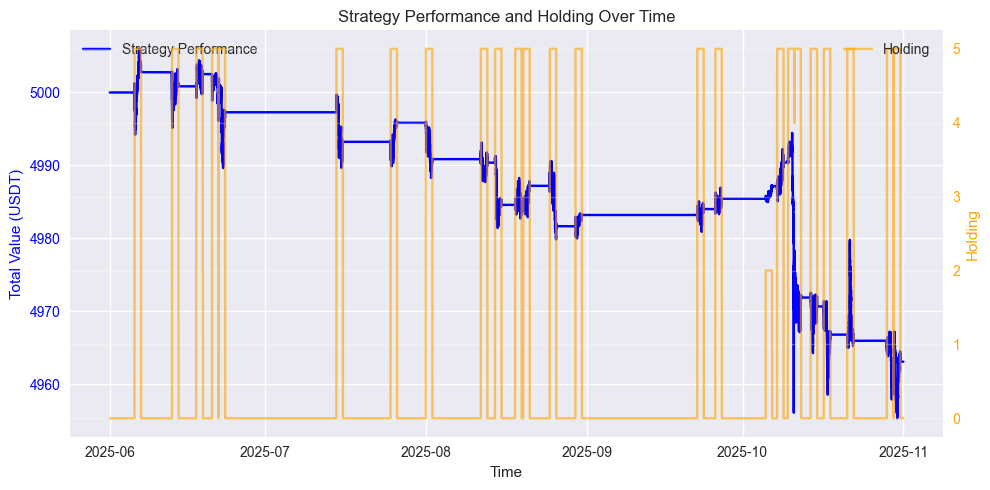

In [54]:
from collections import deque

import numpy as np
import pandas as pd
from tqdm import tqdm



def implement_strategy(
    btc: pd.DataFrame,
    holding_period: int = 30*60,
    threshold: float = -0.02,
    initial_cap: float = 5000,
    trade_size: float = 10,
    fee: float = 0.0005,
    max_hold: int = 5,
):

    prices = btc["Close"].values
    n = len(prices)

    # 预分配结果
    total_value = np.zeros(n)
    holdings_array = np.zeros(n)
    pnl_records = np.zeros(n)  # 每次平仓的收益率记录

    # 策略状态
    capital = initial_cap  # USDT
    amount = 0.0  # 持仓BTC数量
    open_orders = deque()  # 存储未平仓订单 [{time, price, qty}]
    now_holding = 0

    for t in tqdm(range(n), desc="Processing"):
        price_t = prices[t]
        total_value[t] = capital + amount * price_t
        holdings_array[t] = now_holding

        # --- 买入信号 ---
        if (
            t >= 1
            and not np.isnan(coin["growth_in_past_6h"].iloc[t])
            and coin["growth_in_past_6h"].iloc[t] < threshold
            and now_holding < max_hold
        ):
            qty = trade_size / price_t
            cost = trade_size * (1 + fee)

            if capital >= cost:  # 资金充足才买
                capital -= cost
                amount += qty
                now_holding += 1
                open_orders.append({"time": t, "price": price_t, "qty": qty})

        # --- 到期清仓 ---
        while open_orders and (t - open_orders[0]["time"]) >= holding_period:
            order = open_orders.popleft()
            sell_qty = order["qty"]
            sell_revenue = sell_qty * price_t * (1 - fee)

            capital += sell_revenue
            amount -= sell_qty
            now_holding -= 1

            pnl = (
                (price_t - order["price"]) - (order["price"] + price_t) * fee
            ) / order["price"]
            pnl_records[t] = pnl

    # 生成结果
    performance_df = pd.DataFrame({"Total Value": total_value}, index=btc.index)
    holding_series = pd.Series(holdings_array, index=btc.index)
    pnl_series = pd.Series(pnl_records, index=btc.index)
    return performance_df, pnl_series, holding_series

# 运行优化后的策略
strategy_performance, pnls, holding = implement_strategy(coin, trade_size=50.0, initial_cap=5000.0)
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
ax1 = plt.gca()
ax2 = ax1.twinx()


x = [i * 5 for i in range(len(strategy_performance))]  # 每一行对应的分钟数


# 策略表现
ax1.plot(
    strategy_performance.index,
    strategy_performance["Total Value"],
    label="Strategy Performance",
    color="blue",
)
ax1.set_ylabel("Total Value (USDT)", color="blue")
ax1.tick_params(axis="y", labelcolor="blue")

# 持仓
ax2.plot(
    strategy_performance.index,
    holding.values,
    label="Holding",
    color="orange",
    alpha=0.6,
)
ax2.set_ylabel("Holding", color="orange")
ax2.tick_params(axis="y", labelcolor="orange")

plt.title("Strategy Performance and Holding Over Time")
ax1.set_xlabel("Time")
ax1.legend(loc="upper left")
ax2.legend(loc="upper right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [55]:
# 筛选出 pnls 不等于 0 的值
non_zero_pnls = pnls[pnls != 0]

# 打印前几行以验证
print(non_zero_pnls.head())
# 将 pnls 转换为 numpy 数组以便计算
import numpy as np

pnls_array = np.array(non_zero_pnls)

# 计算基本统计指标
stats = {
    "总交易次数": len(pnls_array),
    "平均收益率": np.mean(pnls_array),
    "中位数收益率": np.median(pnls_array),
    "最大收益率": np.max(pnls_array),
    "最小收益率": np.min(pnls_array),
    "标准差": np.std(pnls_array),
    "正收益交易数": np.sum(pnls_array > 0),
    "负收益交易数": np.sum(pnls_array < 0),
    "胜率": np.mean(pnls_array > 0),
    "盈亏比": np.mean(pnls_array[pnls_array > 0])
    / abs(np.mean(pnls_array[pnls_array < 0]))
    if np.any(pnls_array < 0)
    else float("inf"),
    "夏普比率": np.mean(pnls_array) / np.std(pnls_array)
    if np.std(pnls_array) > 0
    else 0,
    "总收益率": np.sum(pnls_array),
}

# 打印统计指标
for key, value in stats.items():
    print(
        f"{key}: {value:.4f}"
        if isinstance(value, (float, np.float64))
        else f"{key}: {value}"
    )

Close Time
2025-06-07 00:13:59.999999    0.011937
2025-06-07 00:14:59.999999    0.012145
2025-06-07 00:15:59.999999    0.011107
2025-06-07 00:16:59.999999    0.011429
2025-06-07 00:17:59.999999    0.009020
dtype: float64
总交易次数: 122
平均收益率: -0.0060
中位数收益率: -0.0022
最大收益率: 0.0173
最小收益率: -0.0708
标准差: 0.0178
正收益交易数: 55
负收益交易数: 67
胜率: 0.4508
盈亏比: 0.4508
夏普比率: -0.3405
总收益率: -0.7375


# 2
dtype: float64
总交易次数: 66
平均收益率: 0.0098
中位数收益率: 0.0051
最大收益率: 0.1770
最小收益率: -0.0847
标准差: 0.0433
正收益交易数: 35
负收益交易数: 31
胜率: 0.5303
盈亏比: 1.6597
夏普比率: 0.2265
总收益率: 0.6477

In [56]:
strategy_performance.index

DatetimeIndex(['2025-06-01 00:00:59.999999', '2025-06-01 00:01:59.999999',
               '2025-06-01 00:02:59.999999', '2025-06-01 00:03:59.999999',
               '2025-06-01 00:04:59.999999', '2025-06-01 00:05:59.999999',
               '2025-06-01 00:06:59.999999', '2025-06-01 00:07:59.999999',
               '2025-06-01 00:08:59.999999', '2025-06-01 00:09:59.999999',
               ...
               '2025-10-31 23:50:59.999999', '2025-10-31 23:51:59.999999',
               '2025-10-31 23:52:59.999999', '2025-10-31 23:53:59.999999',
               '2025-10-31 23:54:59.999999', '2025-10-31 23:55:59.999999',
               '2025-10-31 23:56:59.999999', '2025-10-31 23:57:59.999999',
               '2025-10-31 23:58:59.999999', '2025-10-31 23:59:59.999999'],
              dtype='datetime64[ns]', name='Close Time', length=220320, freq=None)

In [57]:
strategy_performance.to_csv("strategy_performance_BTC_test.csv")